### Introdução CudaPy
---

> __NumPy__ é uma biblioteca em Python que fornece operações eficientes para manipulação de arrays e matrizes usando a CPU. Embora o NumPy seja rápido para muitas operações, ele se torna menos eficiente à medida que o volume de dados aumenta significativamente ou quando o problema pode se beneficiar de paralelismo massivo.

> __CuPy__ é uma biblioteca projetada para operações numéricas usando GPU. As GPUs são projetadas para processamento paralelo massivo, o que as torna altamente eficientes para computações que podem ser divididas em muitas operações simultâneas, como $álgebra$ $linear$, $operações$ $matriciais$, e $deep$ $learning$.

A GPU, com milhares de núcleos, executa muitas operações em paralelo. Isso é ideal para grandes volumes de dados ou computações que podem ser distribuídas em muitas operações simultâneas, como a multiplicação de grandes matrizes ou algoritmos de machine learning.

### __Vantagens do uso da biblioteca CuPy:__

+ *Aproveitamento da GPU:* CuPy permite a execução de operações numéricas diretamente na GPU, que é capaz de realizar processamento paralelo massivo. Isso proporciona um ganho de desempenho significativo em operações como transformadas de Fourier (FFT) em grandes conjuntos de dados.
+ *APIs semelhantes ao NumPy:* A familiaridade das APIs torna a transição de NumPy para CuPy simples e direta para desenvolvedores.
+ *Alta performance:* Para operações intensivas em cálculos, como álgebra linear e convoluções, CuPy oferece tempos de execução muito menores em comparação com cálculos baseados na CPU.
+ *Integração com outras bibliotecas de GPU:* CuPy pode se integrar facilmente com outras bibliotecas de aprendizado profundo e computação científica que também utilizam a GPU.

### __Desvantagens do uso da biblioteca CuPy:__

+ *Dependência de hardware específico:* O uso de CuPy exige uma GPU compatível e drivers CUDA instalados, limitando o uso em máquinas sem suporte a esse hardware.
+ *Complexidade de instalação:* A configuração e instalação de CuPy podem ser mais complicadas devido à necessidade de compatibilidade com CUDA, o que pode ser um obstáculo para usuários iniciantes.
+ *Consumo de memória da GPU:* As GPUs têm uma capacidade de memória menor em comparação com a RAM do sistema, o que pode limitar o tamanho dos dados que podem ser processados de forma eficiente.

### __Conclusão sobre o uso de CuPy:__

O uso da CuPy é altamente benéfico para operações de processamento de sinais, especialmente aquelas que envolvem cálculos intensivos e grandes volumes de dados, como transformadas de Fourier rápidas (FFT). O paralelismo massivo das GPUs permite que essas operações sejam executadas com muito mais eficiência do que em uma CPU. Portanto, para aplicações que requerem desempenho elevado, a CuPy é uma escolha importante, proporcionando aceleração significativa em comparação com o NumPy.

In [1]:
import numpy as np
import cupy as cp
import cupyx.scipy.fft as cufft
import scipy.linalg
import scipy.fft
import time
import matplotlib.pyplot as plt

In [ ]:
# Operação com NumPy (CPU)
start_time = time.time()
x_cpu = np.random.randn(20000, 20000)
y_cpu = np.random.randn(20000, 20000)
z_cpu = x_cpu + y_cpu
print("Tempo de execução com NumPy (CPU):", time.time() - start_time)

# Operação com CuPy (GPU)
start_time = time.time()
x_gpu = cp.random.randn(20000, 20000)
y_gpu = cp.random.randn(20000, 20000)
z_gpu = x_gpu + y_gpu
cp.cuda.Stream.null.synchronize()  # Certifica que todas as operações da GPU estão completas
print("Tempo de execução com CuPy (GPU):", time.time() - start_time)

Tempo de execução com NumPy (CPU): 26.459710359573364
Tempo de execução com CuPy (GPU): 0.5406575202941895


### Exemplo 1 - Resolvendo um sistema de equações lineares.
---
Neste exemplo iremos resolver um sistema de equações lineares usando tanto a CPU (com SciPy) quanto a GPU (com CuPy), comparando o tempo de execução e a precisão dos resultados. Usaremos a biblioteca Matplotlib para visualizar as primeiras soluções, mostrando como é fácil alternar entre CPU e GPU e aproveitar a aceleração da GPU em problemas matemáticos intensivos.
>Queremos resolver esse sistema usando:
  - NumPy e SciPy para resolver na __CPU__.
  - CuPy para resolver na __GPU__.

Tempo de execução na CPU com SciPy: 52.2004 segundos
Tempo de execução na GPU com CuPy: 6.3727 segundos
Diferença máxima entre soluções CPU e GPU: 2.226201e-10


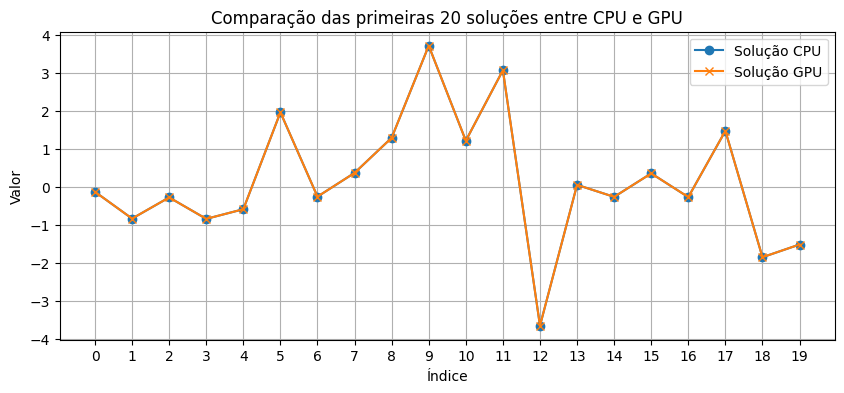

In [ ]:
# Tamanho do sistema, Matriz.
matriz_size = 13000

# 1. Gerar os dados
# Gerando uma matriz A aleatória de MxN e um vetor b de tamanho M
A_cpu = np.random.rand(matriz_size, matriz_size)
b_cpu = np.random.rand(matriz_size)

# 2. Resolver o sistema de equações lineares na CPU usando SciPy
#  Caculando o tempo de execução.
start_time = time.time()
# linalg.solve resolve sistemas lineares no formato Ax = b
x_cpu = scipy.linalg.solve(A_cpu, b_cpu)
cpu_time = time.time() - start_time
print(f"Tempo de execução na CPU com SciPy: {cpu_time:.4f} segundos")

# 3. Transferir os dados para a GPU usando CuPy
A_gpu = cp.array(A_cpu)
b_gpu = cp.array(b_cpu)

# 4. Resolver o sistema de equações lineares na GPU usando CuPy
#  Caculando o tempo de execução.
start_time = time.time()
# linalg.solve resolve sistemas lineares no formato Ax = b
x_gpu = cp.linalg.solve(A_gpu, b_gpu)
cp.cuda.Stream.null.synchronize()
gpu_time = time.time() - start_time
print(f"Tempo de execução na GPU com CuPy: {gpu_time:.4f} segundos")

# 5. Comparar os resultados
# Transferir o resultado de volta para a CPU, para poder comparar.
x_gpu_cpu = cp.asnumpy(x_gpu)

# Verificar se as soluções são aproximadamente iguais
diff = np.max(np.abs(x_cpu - x_gpu_cpu))
print(f"Diferença máxima entre soluções CPU e GPU: {diff:.6e}")

# 6. Visualização dos resultados
# Visualizar os primeiros 20 valores das soluções encontradas para comparação
plt.figure(figsize=(10, 4))
plt.plot(x_cpu[:20], label="Solução CPU", marker='o')
plt.plot(x_gpu_cpu[:20], label="Solução GPU", marker='x')
plt.xticks(range(20))
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.title("Comparação das primeiras 20 soluções entre CPU e GPU")
plt.legend()
plt.grid(True)
plt.show()


### Exemplo 2
---

Considere a função retangular $x(t)$ definida por:
$$x(t) = \begin{cases}
  1, & \text{se } |t| < T_1 \\
  0, & \text{se } |t| > T_1
\end{cases}$$

Calcule a transformada de Fourier $X(ω)$ e plote seu gráfico.

O objetivo desta questão é entender como a Transformada de Fourier de uma função retangular resulta em uma função sinc, e visualizar como a largura do retângulo T_1 afeta o espalhamento de frequência no domínio $ω$.

In [6]:
# Gerando o sinal quadrado.
def generate_signal_square(t, T1):
    signal = cp.where(cp.abs(t) < T1, 1, 0)
    return signal

def fourier_transform(signal, t, T1):
  w = 2 * cp.pi * t
  fft = cp.where( w == 0, 2 * T1, (2 * cp.sin(w * T1)) / w)
  return w, fft

# Parametros do sinal.
t = cp.linspace(-10, 10, 2000)
T1 = 2 * cp.pi
signal = generate_signal_square(t, T1)
omega, fft = fourier_transform(signal, t, T1)

signal = signal.get()
fft = fft.get()
omega = omega.get()
t = t.get()

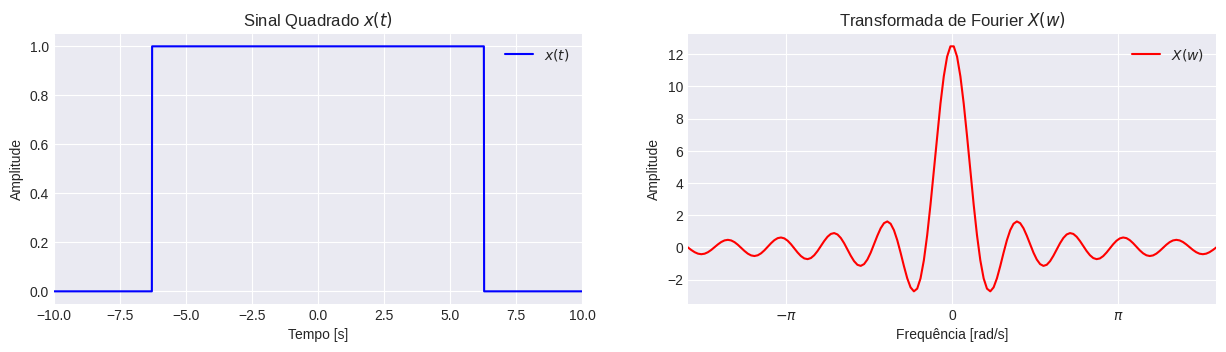

In [7]:
# Visualisando os resultados.
# Configurando os gráficos.

plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 2, figsize=(15, 3.5))

# Plotando gráfico do sinal Quadrado.
axis[0].plot(t, signal, color='b', label = "$x(t)$")
axis[0].set_title("Sinal Quadrado $x(t)$")
axis[0].set_xlabel("Tempo [s]")
axis[0].set_ylabel("Amplitude")
axis[0].set_xlim(-10, 10)
axis[0].legend()

# Plotando o gráfico do espctro X(w).
axis[1].plot(omega, (fft), color='r', label = "$X(w)$")
axis[1].set_xlim(-2 * np.pi, 2 * np.pi)
axis[1].set_xticks([-2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi])
axis[1].set_xticklabels(['$-2\pi$', '$-\pi$', '0', '$\pi$', '$2\pi$'])
axis[1].set_title("Transformada de Fourier $X(w)$")
axis[1].set_xlabel("Frequência [rad/s]")
axis[1].set_ylabel("Amplitude")
axis[1].set_xlim(-5, 5)
axis[1].legend()

plt.show()

### Exemplo 3
---
Plote a saída $Y(ω)$ de um sistema invariante no tempo dado que:
+ $X(ω) = e^{-ω^2}$
+ $H(ω) = 1, \quad |ω| > 1$ \\
Uma função retangular, indicando um filtro passa-faixa ideal.
+ $Y(ω) = X(ω) . H(ω)$

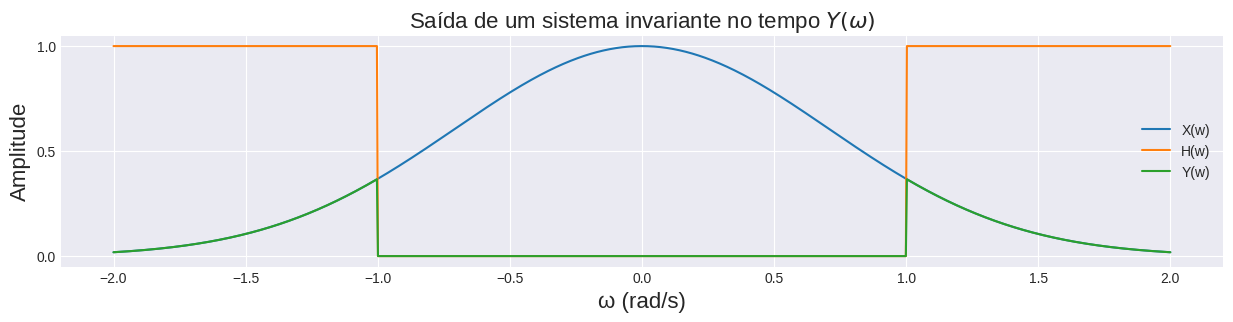

In [9]:
# Definindo o intervalo de frequências
w = cp.linspace(-2, 2, 1000)

# Exemplo de função X(w) (filtro passa-baixa)
def X(w):
    return cp.exp(-w**2)

# Exemplo de função H(w) (filtro passa-faixa ideal)
def H(w):
    return (cp.abs(w) > 1).astype(float)

# Calculando os valores das funções para cada frequência
x = X(w)
h = H(w)
y = h * x

w = w.get()
x = x.get()
h = h.get()
y = y.get()

# Plotando os gráficos
plt.figure(figsize=(15, 3))
plt.yticks(cp.arange(0, 1.1, 0.5).get())
plt.plot(w, x, label='X(w)')
plt.plot(w, h, label='H(w)')
plt.plot(w, y, label='Y(w)')
plt.xlabel('ω (rad/s)', fontsize = 16)
plt.ylabel('Amplitude', fontsize = 16)
plt.title("Saída de um sistema invariante no tempo $Y(\omega)$", fontsize = 16)
plt.legend()
plt.grid(True)
plt.show()

### Exemplo 4
---
Considere um sistema discreto no qual o espectro de frequência $X(Ω)$ é definido por uma função retangular de amplitude unitária centrada em $Ω=0$, com largura total de $2W$, conforme representado na figura abaixo. O espectro é periódico com período $2π$. Deseja-se determinar a representação no domínio do tempo do sinal $x(n)$ correspondente a esse espectro de frequência utilizando a Transformada Inversa de Fourier.

Verifique que a solução obtida para $x(n)$ é do tipo
$x(n) = \frac{sin(Wn)}{πn}$ e ajuste do valor para
$x(0) = \frac{W}{𝜋}$.

In [12]:
# Definindo parâmetros
W = cp.pi / 3
Omega = cp.linspace(-4 * cp.pi, 4 * cp.pi, 2000)
n = cp.arange(-25, 26)
Xw = cp.zeros_like(Omega)

# Criação do sinal periódico, altere o range caso queira alterar o tamanho.
for k in range(-2, 3):
    Xw[(Omega >= -W + 2 * k * cp.pi) & (Omega <= W + 2 * k * cp.pi)] = 1

# Cálculo de x(n) usando a fórmula analítica
# cp.sinc(x) = sin(pi*x) / (pi*x)
x_n = cp.sinc(W * n / cp.pi) * W / cp.pi
x_n[n == 0] = W / cp.pi

# Transformando as variaveis em formato numpy para plotar.
Omega = Omega.get()
Xw = Xw.get()
n = n.get()
x_n = x_n.get()

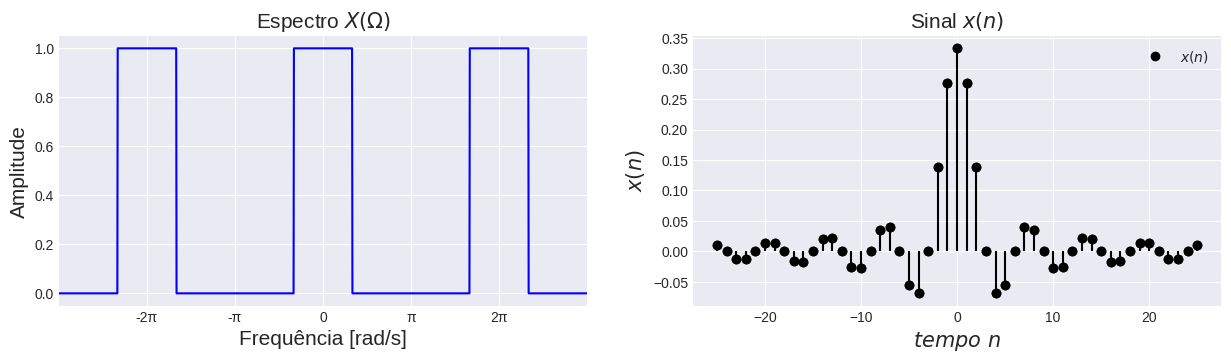

In [13]:
# Configurando os gráficos.
plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 2, figsize=(15, 3.5))

# Plotando gráfico de X(Omega)
axis[0].plot(Omega, Xw, color='b')
axis[0].set_xlim(-3 * np.pi, 3 * np.pi)
axis[0].set_xticks([-2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi], ["-2π", "-π", "0", "π", "2π"])
axis[0].set_title('Espectro $X(\Omega)$', fontsize = 15)
axis[0].set_xlabel('Frequência [rad/s]', fontsize = 15)
axis[0].set_ylabel('Amplitude', fontsize = 15)

# Plotando gráfico de x(n)
axis[1].plot(n, x_n, "o", color = "k", label = "$x(n)$")
axis[1].stem(n, x_n, markerfmt='ko', linefmt='k-', basefmt=" ")
axis[1].set_title('Sinal $x(n)$', fontsize = 15)
axis[1].set_xlabel('$tempo \ n$', fontsize = 15)
axis[1].set_ylabel('$x(n)$', fontsize = 15)
axis[1].legend(loc = "best")

plt.show()

### Exemplo 5
---
Considere dois sinais $x_1(n)$ e $x_2(n)$ definidos pela função sinc com diferentes frequências de corte $w_1$  e
$w_2$ . As expressões para os sinais são dadas por:

Gere os sinais $x_1(n)$ e $x_2(n)$ dado por $N=500.$

Calcule os espectros de frequência $X_1(Ω) \ \text{e}\ X_2(Ω)$ usando a Transformada Rápida de Fourier (FFT). Plote os gráficos dos sinais $x_1(n)$ e $x_2(n)$ e seus respectivos espectros de magnitude $X_1(Ω) \ \text{e}\ X_2(Ω)$.

In [16]:
# Parametro para o sinal.
N = 500
n = cp.arange(-N//2, N//2)
w1 = cp.pi / 2
w2 = 3 * cp.pi / 4

# Criando os sinais x1(n) e x2(n)
x1_n = cp.sinc(w1 * n / cp.pi) * w1 / cp.pi
x2_n = cp.sinc(w2 * n / cp.pi) * w2 / cp.pi

# Calculando os espectros Xw1 e Xw2.
Xw1 = cufft.fft(x1_n, N)
Xw2 = cufft.fft(x2_n, N)
Xw1 = cp.abs(cufft.fftshift(Xw1))
Xw2 = cp.abs(cufft.fftshift(Xw2))
omega = cp.linspace(-cp.pi, cp.pi, N)

# Transformando as variaveis em formato numpy para plotar.
n = n.get()
x1_n = x1_n.get()
x2_n = x2_n.get()
omega = omega.get()
Xw1 = Xw1.get()
Xw2 = Xw2.get()

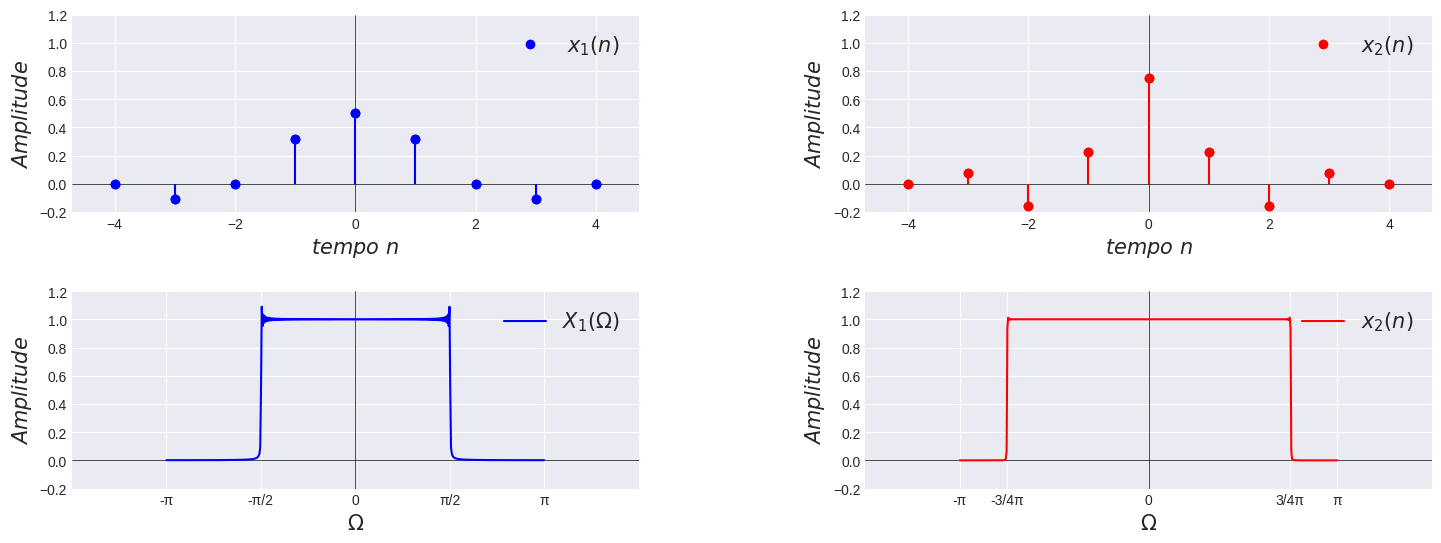

In [17]:
# Configurando os gráficos.
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(2, 2, figsize=(17, 6))
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)

# Aplicando configurações gerais a todos os eixos
for ax in axis.flatten():
    ax.set_xlim(-1.5*np.pi, 1.5*np.pi)
    ax.set_ylim(-0.2, 1.2)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_ylabel("$Amplitude$", fontsize = 15)

axis[0, 0].plot(n, x1_n, "o", color="b", label = "$x_1(n)$")
axis[0, 0].stem(n, x1_n, markerfmt="bo", linefmt="b-", basefmt=" ")
axis[0, 0].set_xlabel("$tempo \ n$", fontsize = 15)
axis[0, 0].legend(loc = "best", fontsize = 15)

axis[0, 1].plot(n, x2_n, "o", color="red", label = "$x_2(n)$")
axis[0, 1].stem(n, x2_n, markerfmt="ro", linefmt="r-", basefmt=" ")
axis[0, 1].set_xlabel("$tempo \ n$", fontsize = 15)
axis[0, 1].legend(loc = "best", fontsize = 15)

axis[1, 0].plot(omega, Xw1, color="b", label = "$X_1(\Omega)$")
axis[1, 0].set_xticks([-1/2 * np.pi, -np.pi, 0, np.pi, 1/2 * np.pi], ["-π/2", "-π", "0", "π", "π/2"])
axis[1, 0].set_xlabel("$\Omega$", fontsize = 15)
axis[1, 0].legend(loc = "best", fontsize = 15)

axis[1, 1].plot(omega, Xw2, color="red", label = "$x_2(n)$")
axis[1, 1].set_xticks([-3/4 * np.pi, -np.pi, 0, np.pi, 3/4 * np.pi], ["-3/4π","-π", "0", "π", "3/4π"])
axis[1, 1].set_xlabel("$\Omega$", fontsize = 15)
axis[1, 1].legend(loc = "best", fontsize = 15)

plt.show()

### Exemplo 6
---


Dado um sinal discreto definido por:
$$x(n) = \left( \frac{-1}{3}\right)^n u(n) -
\left( \frac{1}{2} \right)^n u(-n-1),$$
onde $u(n) $ é uma função unitária.
1. Calcular a Transformada Z de $x(n)$ e representar graficamente o módulo de $X(z).$
2. Determinar os polos e zeros do sistema associado e plotar a região de convergência (ROC) no plano complexo.

In [18]:
# Parametros do sinal.
a, b = -1/3, 1/2
n = cp.arange(-20,20)
omega = cp.linspace(-cp.pi, cp.pi, 1000)

# Definindo o sinal unitário u(n).
def u(n):
    return (n >= 0).astype(float)

# Definindo o sinal de x(n).
x_n = (a**n) * u(n) - (b**n) * u(-n -1)

# Função para calcular a Transformada Z manualmente.
def Z_transform(x_n, n, z):
  return sum([x_n[i] * z**(-n[i]) for i in range(len(n))])

# Calculando os valores de z1 e z2.
z1 = a * cp.exp(1j * omega)
z2 = b * cp.exp(1j * omega)
roc_circle = z2 - z1

# Calculando o valor de X(z).
X_z = cp.abs(Z_transform(x_n, n, roc_circle))
X_z = X_z / cp.max(X_z)

# Transformando as variaveis em formato numpy para plotar.
n = n.get()
x_n = x_n.get()
omega = omega.get()
z1 = z1.get()
z2 = z2.get()
X_z = X_z.get()

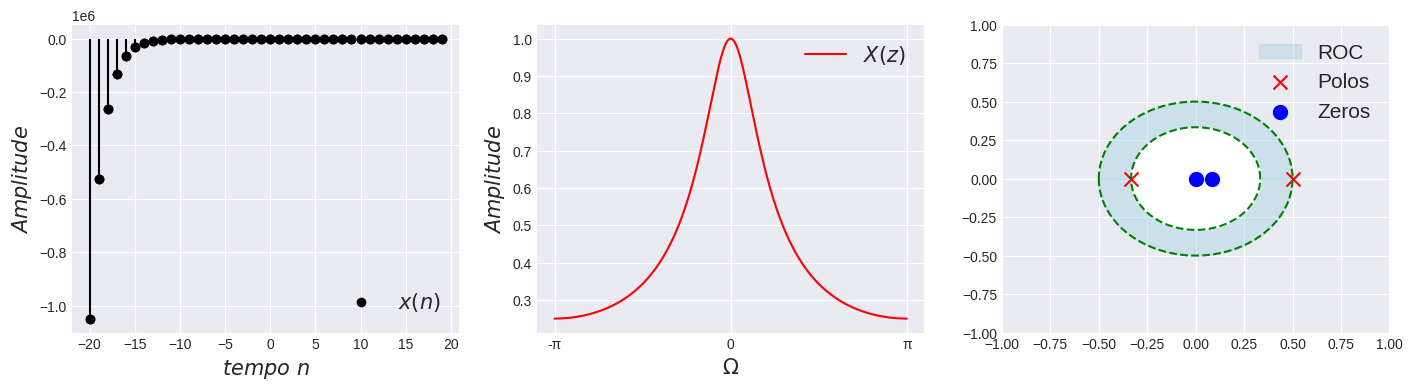

In [19]:
# Configurações para o gráfico
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(1, 3, figsize=(17, 4))

# Plotando gráfico de x(n).
axis[0].plot(n, x_n, "o", color = "k", label = "$x(n)$")
axis[0].stem(n, x_n, markerfmt="ko", linefmt="k-", basefmt=" ")
axis[0].set_xlabel("$tempo \ n$", fontsize = 15)
axis[0].set_ylabel("$Amplitude$", fontsize = 15)
axis[0].legend(loc = "best", fontsize = 15)

# Plotando gráfico de X(z).
axis[1].plot(omega, X_z, color = "r", label = "$X(z)$")
axis[1].set_xlim(-1.1*np.pi, 1.1*np.pi)
axis[1].set_xticks([-np.pi, 0, np.pi], ["-π", "0", "π"])
axis[1].set_xlabel("$\Omega$", fontsize = 15)
axis[1].set_ylabel("$Amplitude$", fontsize = 15)
axis[1].legend(loc = "best", fontsize = 15)

# Plotando o gráfico da ROC e dos polos no plano z.
axis[2].set_xlim(-1, 1)
axis[2].set_ylim(-1, 1)
axis[2].plot(z1.real, z1.imag, "g--")
axis[2].plot(z2.real, z2.imag, "g--")
axis[2].fill_between(z2.real, z2.imag, color="lightblue", alpha=0.5, label="ROC")
axis[2].fill_between(z1.real, z1.imag, color="w")
axis[2].scatter([-1/3,1/2],[0,0], color="red", label="Polos", marker = "x", s = 100)
axis[2].scatter([0,1/12],[0,0], color="blue", label="Zeros", marker = "o", s = 100)
axis[2].legend(loc = "best", fontsize = 15)

plt.show()

### Exemplo 7 - Transformada de Fourier (FFT) em um sinal.
---
A Transformada de Fourier é amplamente utilizada para transformar sinais do domínio do tempo para o domínio da frequência. Neste exemplo, vamos criar um sinal, aplicar a FFT tanto na CPU (com NumPy e SciPy) quanto na GPU (com CuPy e cuFFT), e então comparar os resultados visualmente e em termos de desempenho.
> Objetivos deste exemplo:
  + Criar um sinal no domínio do tempo a partir de duas ondas senoidais.
  + Aplicar a Transformada de Fourier na CPU usando Numpy e SciPy.
  + Aplicar a Transformada de Fourier na GPU usando Cupy e CuFFT.
  + Comparar os resultados graficamente.
  + Medir o tempo de execução nos dois casos.

In [23]:
# 1. Gerar o sinal no domínio do tempo.
# Criamos um sinal composto de duas ondas senoidais de diferentes frequências
def generate_signal(t):
    # Criando as frequências de 5Hz e 20Hz e suas respectivas amplitudes.
    freq1 = 20
    freq2 = 50
    amp1 = 1
    amp2 = 0.5
    # Gerando o sinal.
    signal = (amp1 * np.sin(2 * np.pi * freq1 * t)) + (amp2 * np.sin(2 * np.pi * freq2 * t))
    return signal

# Parâmetros do sinal
# Frequência de amostragem (Hz), deve ser no mínimo o dobro das frequências do sinal.
Fs = 200
T = 1 / Fs
# Tempo de amostra.
t = np.arange(0, 3, T)
N = len(t)

# Gerar o sinal
signal_cpu = generate_signal(t)

print(f"Amostras por período: {N}")
print(f"Período de amostragem: {T}")

Amostras por período: 600
Período de amostragem: 0.005


In [24]:
# 2. Aplicar a Transformada de Fourier na CPU usando Numpy e SciPy.
# Iniciando contagem do tempo.
start_time = time.time()
# Calculando FFT, retornando a amplitude e fase e sua frequência após a FFT.
fft_cpu = scipy.fft.fft(signal_cpu)
fft_freq_cpu = scipy.fft.fftfreq(N, T)
cpu_time = time.time() - start_time
print(f"Tempo de execução com SciPy (CPU): {cpu_time:.6f} segundos")

# 3. Aplicar a Transformada de Fourier na GPU usando Cupy e CuFFT.
# Transferindo o sinal de CPU para GPU.
signal_gpu = cp.array(signal_cpu)

# Iniciando a contagem do tempo para FFT na GPU (cuFFT).
start_time = time.time()
# Calculando FFT, retornando a amplitude e fase e sua frequência após a FFT.
fft_gpu = cufft.fft(signal_gpu)
fft_freq_gpu = cp.asnumpy(fft_freq_cpu)
cp.cuda.Stream.null.synchronize()  # Sincronizar a GPU para garantir que a operação esteja completa
gpu_time = time.time() - start_time
print(f"Tempo de execução com cuFFT (GPU): {gpu_time:.6f} segundos")

Tempo de execução com SciPy (CPU): 0.000669 segundos
Tempo de execução com cuFFT (GPU): 0.001686 segundos


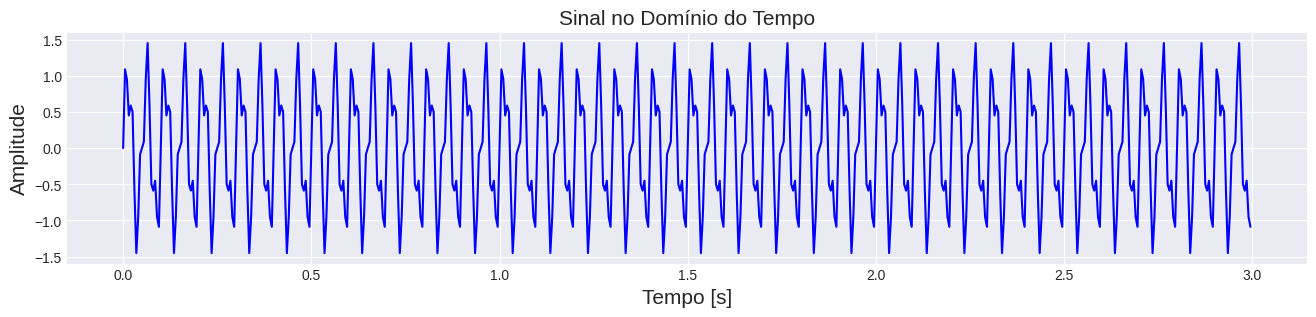

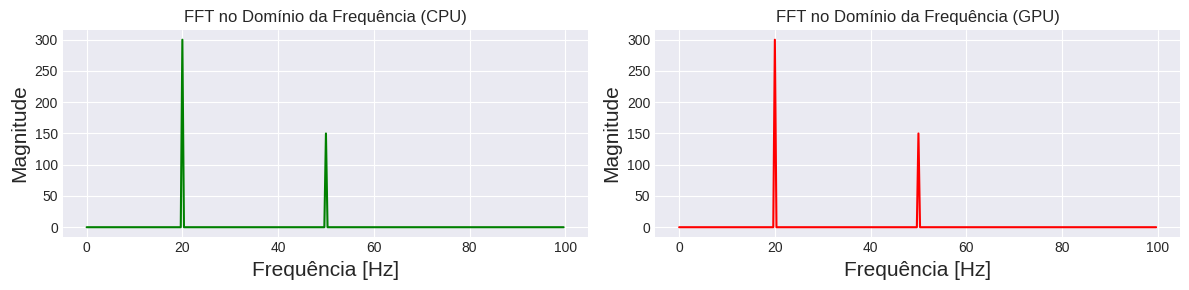

In [38]:
# 4. Comparar os resultados
# Transformar o resultado da GPU de volta para a CPU para comparação
fft_gpu_cpu = cp.asnumpy(fft_gpu)

# 5. Visualizar os resultados usando Matplotlib
plt.style.use('seaborn-v0_8-darkgrid')

# Sinal no domínio do tempo
plt.figure(figsize=(16, 3))
plt.plot(t, signal_cpu, color='b')
plt.title('Sinal no Domínio do Tempo', fontsize = 15)
plt.xlabel('Tempo [s]', fontsize = 15)
plt.ylabel('Amplitude', fontsize = 15)

fig, axis = plt.subplots(1, 2, figsize=(12, 3))

# FFT no domínio da frequência (CPU)
# Seleciona apenas a metade inicial das frequências, que é a parte util.
axis[0].plot(fft_freq_cpu[:N//2], np.abs(fft_cpu[:N//2]), color='g')
axis[0].set_title('FFT no Domínio da Frequência (CPU)')
axis[0].set_xlabel('Frequência [Hz]', fontsize = 15)
axis[0].set_ylabel('Magnitude', fontsize = 15)

# FFT no domínio da frequência (GPU)
# Seleciona apenas a metade inicial das frequências, que é a parte util.
axis[1].plot(fft_freq_gpu[:N//2], np.abs(fft_gpu_cpu[:N//2]), color='r')
axis[1].set_title('FFT no Domínio da Frequência (GPU)')
axis[1].set_xlabel('Frequência [Hz]', fontsize = 15)
axis[1].set_ylabel('Magnitude', fontsize = 15)

plt.tight_layout()
plt.show()

### Exemplo 8
---
Considere um sinal composto por várias componentes senoidais de diferentes amplitudes e frequências. O código fornecido implementa uma série de operações para gerar e analisar esse sinal.

1. O sinal é construído pela soma de funções senoides, com amplitudes e frequências fornecidas nos vetores amp e freq, respectivamente, e amostrado em uma faixa de tempo t.

2. Em seguida, é calculada a Transformada Discreta de Fourier (DFT) do sinal gerado. O objetivo é analisar a distribuição espectral do sinal, ou seja, identificar as frequências presentes no sinal e suas respectivas amplitudes.

In [41]:
# Calculando sinal.
def signal(ap, fq, t):
    return sum([amp * cp.sin(2 * cp.pi * freq * t) for amp, freq in zip(ap, fq)])

# Calculando a DFT.
def dft(x):
    N = len(x)
    n = cp.arange(N)
    k = n.reshape((N, 1))
    M = cp.exp(-2j * cp.pi * n * k / N)
    return cp.dot(M, x) / N

# Parametros do sinal.
tx = 100
T = 1/tx
t = cp.arange(0, 1, T)
amp = cp.array([9, 10, 2.3])
freq = cp.array([2, 1, 10])

# Gerando sinal.
x = signal(amp, freq, t)
Xw = dft(x)
N = len(Xw)
freq = (cp.arange(N) * tx) / N

# Transformando as variaveis em formato numpy para plotar.
x = x.get()
Xw = Xw.get()
freq = freq.get()
t = t.get()

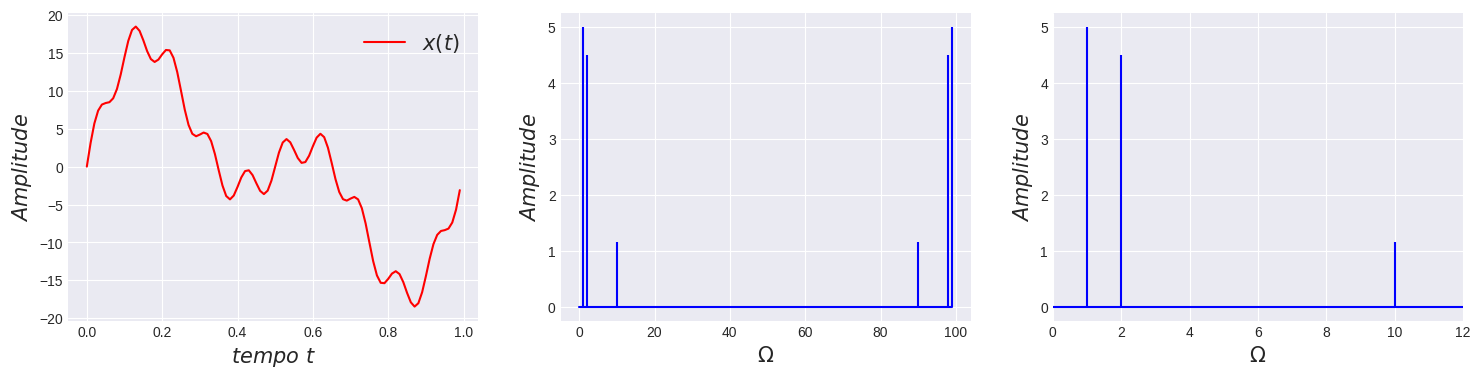

In [42]:
# Configurações para o gráfico
plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plotando gráfico de x(t)
axes[0].plot(t, x, color = "r", label = "$x(t)$")
axes[0].set_xlabel("$tempo \ t$", fontsize = 15)
axes[0].set_ylabel("$Amplitude$", fontsize = 15)
axes[0].legend(loc = "best", fontsize = 15)

# Plotando gráfico de X(w).
axes[1].stem(freq, np.abs(Xw), markerfmt="", linefmt="b-", basefmt="-b")
axes[1].set_xlabel("$\Omega$", fontsize = 15)
axes[1].set_ylabel("$Amplitude$", fontsize = 15)

# Plotando gráfico de X(w).
axes[2].stem(freq[: N // 2], np.abs(Xw)[:N // 2], markerfmt=" ", linefmt="b-", basefmt="-b")
axes[2].set_xlim(0, 12)
axes[2].set_xlabel("$\Omega$", fontsize = 15)
axes[2].set_ylabel("$Amplitude$", fontsize = 15)

plt.show()

### Referências:
---
1. **OPPENHEIM, A. V.; WILLSKY, A. S.** *Signals and Systems*. 2ª ed. New Jersey: Prentice Hall, 1997.
2. **Tan, L., & Jiang, J.**. *Digital Signal Processing: Fundamentals and Applications*. 3ª Edição. AP, 2019
3. **Diniz, P. S. R., Silva, E. A. B. da, & Netto, S. L.**. *Processamento Digital de Sinais: Projeto e Análise de Sistemas*. 2ª Edição. Bookman, 2014
4. **Medium**. *Implementing the Discrete Fourier Transform in Python*. Disponível em: [https://medium.com/...implementing-the-discrete-fourier-transform-in-python-978dedded5bc](https://medium.com/@positive.delta.hm/implementing-the-discrete-fourier-transform-in-python-978dedded5bc). Acessado em: 16 de novembro de 2024.